# Example 2: OR-OSPINN vs CFD, CBSQI, and DQM



## OR-OSPINN Training

This cell trains the Example 2 optimized Schwarz PINN model at the selected iteration checkpoint and keeps the original training output visible.


In [ ]:
# @title Example 2: OR-OSPINN training, seed 1234 (iteration 126)
# Purpose: Train the Example 2 OR-OSPINN model for seed 1234 at iteration 126.

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math
from math import pi
from concurrent.futures import ThreadPoolExecutor
import time

torch.manual_seed(1234); np.random.seed(1234)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {
    "metric": float("inf"),
    "it": 0,
    "z1": None,
    "z2": None,
}
def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)

L, delta = 1.0, 0.3
Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 126
tol      = 1e-5
l2eps    = 1e-5
WARM_START = True

def phi0(x):
    return x**2 * (1.0 - x)**2

def phi0pp(x):
    return 12.0*x**2 - 12.0*x + 2.0

def u_exact(x, t):
    return phi0pp(x) * torch.cos(t)

def v_exact(x, t):
    return -phi0(x) * torch.sin(t)

def f_rhs(x, t):
    return (24.0 - phi0(x)) * torch.cos(t)

def z_exact(x, t):
    return torch.cat([u_exact(x, t), v_exact(x, t)], dim=1)

def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

def build_complex_kernels(a, sign):
    ω   = 2*np.pi*np.fft.fftfreq(Nt, d=dt)
    eta = 1e-3/dt
    k   = np.sqrt(ω + 1j*eta)
    ka  = k * a

    s, c = np.sin(ka), np.cos(ka)
    s = np.where(np.abs(s)>1e-9, s, np.sign(np.real(s))*1e-9 + 0j)

    spec = sign * (k * c / s)

    spec[0] = sign * (1.0/a)
    K  = np.fft.ifft(spec) / dt
    Ka = K.real.astype(np.float32)
    Kb = K.imag.astype(np.float32)
    return torch.tensor(Ka, dtype=torch.float32, device=device), \
           torch.tensor(Kb, dtype=torch.float32, device=device)

def build_toeplitz(K):
    Nt_ = K.numel()
    W   = torch.zeros(Nt_, Nt_, device=device, dtype=K.dtype)
    for k in range(Nt_):
        W[k, :k+1] = K[:k+1].flip(0)
    return W * dt

Ka1, Kb1 = build_complex_kernels(L - delta, +1)
Ka2, Kb2 = build_complex_kernels(delta,     -1)
Wa1, Wb1 = build_toeplitz(Ka1), build_toeplitz(Kb1)
Wa2, Wb2 = build_toeplitz(Ka2), build_toeplitz(Kb2)

def interface_LHS_complex(net, xt_if_all, Wa, Wb):
    xtg  = make_grad(xt_if_all)
    out  = net(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return du + Ra + JRb, out

def build_target_from_other_complex(net_other, xt_if_all, Wa, Wb):
    xtg  = xt_if_all.detach().clone().requires_grad_(True)
    out  = net_other(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return (du + Ra + JRb).detach()

class Net(nn.Module):
    def __init__(self, depth=6, width=48):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)

        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)

        u0 = phi0pp(x)
        v0 = torch.zeros_like(x)

        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]

        u_bc = u0 + 2.0 * (torch.cos(t) - 1.0)

        u = u_bc + Sx * t * u_hat
        v = v0   + Sx * t * v_hat

        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

Ni_int1, Ni_int2 = 100,100
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

t_all     = torch.arange(Nt, device=device).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), delta, device=device)
xt_if_all = torch.cat([x_if_all, t_all], 1)

z1, z2 = new_model(1), new_model(2)

def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device)
    t = (Tmin + torch.arange(Nt, device=device) * dt).clamp(max=Tmin + (Nt-1)*dt)
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()

    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))

@torch.no_grad()
def plot_piecewise_at_t(
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    L: float = 1.0,
    n1: int = 400,
    n2: int = 400,
    comp: int = 0,
    save_path: str | None = None,
    show_gap: bool = True,
    show_fig: bool = False,
):
    """
    Plot z1 on [0,delta) and z2 on [delta,L] at fixed time t_value.
    If model output has 2 columns, 'comp' selects the component (0=u, 1=v).
    Returns a dict with the pointwise interface gap at x=delta.
    """

    def _first_param_device_dtype(m):
        p = next(m.parameters(), None)
        return (p.device, p.dtype) if p is not None else (torch.device('cpu'), torch.float32)

    dev1, dt1 = _first_param_device_dtype(z1_model)
    dev2, dt2 = _first_param_device_dtype(z2_model)
    use_dev = dev1 if dev1.type != 'cpu' else dev2
    use_dt  = dt1

    x1 = torch.linspace(0.0, float(delta), steps=max(n1, 2), device=use_dev, dtype=use_dt)
    if x1.numel() > 1: x1 = x1[:-1]
    x2 = torch.linspace(float(delta), float(L), steps=max(n2, 2), device=use_dev, dtype=use_dt)

    t1 = torch.full_like(x1, float(t_value))
    t2 = torch.full_like(x2, float(t_value))
    xt1 = torch.stack([x1, t1], dim=1)
    xt2 = torch.stack([x2, t2], dim=1)

    z1_model.eval(); z2_model.eval()
    y1 = z1_model(xt1)
    y2 = z2_model(xt2)

    def _pick_column(Y):
        if Y.ndim == 1:        return Y
        if Y.shape[1] == 1:    return Y[:, 0]
        if Y.shape[1] >= 2:    return Y[:, comp]
        raise ValueError("Unsupported model output shape.")

    y1c = _pick_column(y1)
    y2c = _pick_column(y2)

    gap_info = None
    if show_gap:
        xt_delta = torch.tensor([[float(delta), float(t_value)]], device=use_dev, dtype=use_dt)
        y1d = _pick_column(z1_model(xt_delta)).item()
        y2d = _pick_column(z2_model(xt_delta)).item()
        gap_info = dict(x=float(delta), z1=y1d, z2=y2d, gap=y1d - y2d)

    x1_np, y1_np = x1.detach().cpu().numpy(), y1c.detach().cpu().numpy()
    x2_np, y2_np = x2.detach().cpu().numpy(), y2c.detach().cpu().numpy()

    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot(x1_np, y1_np, linewidth=1.8, label=r"$z_1(x,t_\star)$ on $[0,\delta)$")
    ax.plot(x2_np, y2_np, linewidth=1.8, label=r"$z_2(x,t_\star)$ on $[\delta,L]$")
    ax.axvline(float(delta), linestyle="--", linewidth=1.0)

    if show_gap and gap_info is not None:
        ax.scatter([gap_info["x"]], [gap_info["z1"]], s=30, zorder=3, label=r"$z_1(\delta,t_\star)$")
        ax.scatter([gap_info["x"]], [gap_info["z2"]], s=30, zorder=3, label=r"$z_2(\delta,t_\star)$")

    ax.set_xlabel("x"); ax.set_ylabel(f"component {comp}")
    ax.set_xlim(0.0, float(L)); ax.grid(True, linewidth=0.4, alpha=0.4)
    ttl_gap = "" if gap_info is None else f", gap={gap_info['gap']:.2e}"
    ax.set_title(fr"Piecewise at $t_\star={t_value}$ (comp={comp}), $\delta={delta}$" + ttl_gap)
    ax.legend(loc="best", fontsize=9, frameon=True)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=160)
    if show_fig:
        plt.show()
    plt.close(fig)

    return gap_info
def after_iter_plot(
    it: int,
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    outdir: str = "content/mnt/iter_plots",
    L: float = 1.0
):
    """
    Save two figures per iteration (u and v) at time t_value.
    Returns the gaps at x=delta for u and v.
    """
    os.makedirs(outdir, exist_ok=True)
    p_u = os.path.join(outdir, f"u_iter{it:03d}.png")
    p_v = os.path.join(outdir, f"v_iter{it:03d}.png")

    g_u = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=0, save_path=p_u, show_gap=True)
    g_v = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=1, save_path=p_v, show_gap=True)
    return {"gap_u": (None if g_u is None else g_u["gap"]),
            "gap_v": (None if g_v is None else g_v["gap"])}

def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()

def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa1, Wb1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa2, Wb2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    _,_,ux1,vx1 = deriv_all(out1, xtg); du1 = torch.cat([ux1, vx1], 1)
    _,_,ux2,vx2 = deriv_all(out2, xtg); du2 = torch.cat([ux2, vx2], 1)

    Ra1_1 = Wa1 @ out1; Rb1_1 = Wb1 @ out1; JRb1_1 = torch.stack([-Rb1_1[:,1], Rb1_1[:,0]], 1)
    Ra1_2 = Wa1 @ out2; Rb1_2 = Wb1 @ out2; JRb1_2 = torch.stack([-Rb1_2[:,1], Rb1_2[:,0]], 1)
    L1_z1 = du1 + Ra1_1 + JRb1_1
    L1_z2 = du2 + Ra1_2 + JRb1_2

    Ra2_2 = Wa2 @ out2; Rb2_2 = Wb2 @ out2; JRb2_2 = torch.stack([-Rb2_2[:,1], Rb2_2[:,0]], 1)
    Ra2_1 = Wa2 @ out1; Rb2_1 = Wb2 @ out1; JRb2_1 = torch.stack([-Rb2_1[:,1], Rb2_1[:,0]], 1)
    L2_z2 = du2 + Ra2_2 + JRb2_2
    L2_z1 = du1 + Ra2_1 + JRb2_1

    r1 = torch.sqrt(((L1_z1 - L1_z2)**2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1)**2).mean()).item()
    return r1, r2

t_decomp_total0 = _now()
t_warm = 0.0
iter_times = []

if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, xt_int1, 300, 1e-3)
        f2 = pool.submit(warm_start, z2, xt_int2, 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")

    target_R1_full = build_target_from_other_complex(z2, xt_if_all, Wa1, Wb1)
    target_R2_full = build_target_from_other_complex(z1, xt_if_all, Wa2, Wb2)

    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True
    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()
    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")
    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] z1(δ,⋅)−z2(δ,⋅)(t)={diffz:.3e}")
    after_iter_plot(it, z1, z2, t_value=0.2, delta=delta, outdir="content/mnt/iter_plots", L=L)
    if max(L2u, L2v) <= l2eps or diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Decomposed (z1/z2) total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with complex DtN (Example 3).")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final (last-iteration) models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 15.753 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 19.770 s
r1=1.323e-01  r2=5.140e-02  (max=1.323e-01)
[iter 1] L2(u)=6.680e-03  L2(v)=1.147e-02
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=1.286e-02

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 16.562 s
r1=4.780e-02  r2=6.861e-02  (max=6.861e-02)
[iter 2] L2(u)=5.032e-03  L2(v)=1.109e-02
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=8.834e-03

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 14.722 s
r1=6.152e-02  r2=2.784e-02  (max=6.152e-02)
[iter 3] L2(u)=5.736e-03  L2(v)=6.323e-03
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=5.138e-03

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 11.186 s
r1=3.141e-02  r2=3.282e-02  (max=3.282e-02)
[iter 4] L2(u)=6.880e-03  L2(v)=3.651e-03
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=4.296e-03

=== Schwarz iteration 5 (global in time, parallel J

## Displacement Reconstruction

This cell reconstructs the displacement `y` from the learned `u` and `v` fields.


In [ ]:
# @title Reconstruct displacement y from u and v
# Purpose: Train the displacement model Y using the learned u and v fields.

import torch, torch.nn as nn, torch.optim as optim
from math import pi

BEST_Z1_CKPT = "checkpoints/final_last_z1.pt"
BEST_Z2_CKPT = "checkpoints/final_last_z2.pt"

def phi0(x):
    return x**2 * (1.0 - x)**2

def phi0pp(x):
    return 12.0*x**2 - 12.0*x + 2.0

def y_exact(x, t):
    return phi0(x) * torch.cos(t)

def u_exact(x, t):
    return phi0pp(x) * torch.cos(t)

def v_exact(x, t):
    return -phi0(x) * torch.sin(t)

class ZNet(nn.Module):
    def __init__(self, depth=6, width=48):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)
        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)

        u0 = phi0pp(x)
        v0 = torch.zeros_like(x)

        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]

        u_bc = u0 + 2.0 * (torch.cos(t) - 1.0)
        u = u_bc + Sx * t * u_hat
        v = v0   + Sx * t * v_hat

        return torch.cat([u, v], dim=1)

z1 = ZNet().to(device)
z2 = ZNet().to(device)
z1.load_state_dict(torch.load(BEST_Z1_CKPT, map_location=device))
z2.load_state_dict(torch.load(BEST_Z2_CKPT, map_location=device))
z1.eval(); z2.eval()
print("Loaded best z1/z2 from checkpoints.")

def l2_errors_uv(z1, z2, delta, Nx=100):
    x = torch.linspace(0.0, 1.0, Nx, device=device)
    t = (Tmin + torch.arange(Nt, device=device) * dt).clamp(max=Tmin + (Nt-1)*dt)
    X, Tm = torch.meshgrid(x, t, indexing='ij')
    XT = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
    with torch.no_grad():
        out1 = z1(XT); out2 = z2(XT)
        Z = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)
        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)
        Ue = u_exact(X.reshape(-1,1), Tm.reshape(-1,1)).reshape(Nx, Nt)
        Ve = v_exact(X.reshape(-1,1), Tm.reshape(-1,1)).reshape(Nx, Nt)
        L2_u = torch.mean((U - Ue)**2).sqrt().item()
        L2_v = torch.mean((V - Ve)**2).sqrt().item()
    return L2_u, L2_v

L2u_z, L2v_z = l2_errors_uv(z1, z2, delta, Nx=150)
print(f"[z1/z2 checkpoints] L2(u)={L2u_z:.3e}  L2(v)={L2v_z:.3e}")

@torch.no_grad()
def uv_from_subdomains(xt: torch.Tensor) -> torch.Tensor:
    """
    xt: [N,2] with cols (x,t). Returns [N,2] = [u,v],
    using z1 on x<=delta and z2 on x>delta.
    """
    z1.eval(); z2.eval()
    out1 = z1(xt)
    out2 = z2(xt)
    mask = (xt[:, 0:1] <= delta).expand_as(out1)
    return torch.where(mask, out1, out2)

class Tiny1D(nn.Module):
    """C_hat(t)"""
    def __init__(self, width=24, depth=5):
        super().__init__()
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth-1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, t):
        return self.net(t)

class Tiny2D(nn.Module):
    """F(x,t)"""
    def __init__(self, width=48, depth=4):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 1)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=nn.init.calculate_gain('tanh'))
                nn.init.zeros_(m.bias)
    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        return self.out(z)

class YModel(nn.Module):
    """
    HARD BC/IC ansatz for Example 3:
      y(x,t) = phi0(x) * C(t) + [phi0(x)] * t^2 * F(x,t),
      with C(t) = 1 + t^2 * C_hat(t).
    Then:
      y(x,0) = phi0(x),
      y_t(x,0) = 0,
      y(0,t)=y(1,t)=0 because phi0(0)=phi0(1)=0.
    """
    def __init__(self):
        super().__init__()
        self.C_hat = Tiny1D(width=24, depth=5)
        self.F     = Tiny2D(width=48, depth=4)
    def forward(self, xt):
        x = xt[:, 0:1]
        t = xt[:, 1:2]
        base = phi0(x)
        C  = 1.0 + (t**2) * self.C_hat(t)
        Sx = base
        y  = base * C + Sx * (t**2) * self.F(xt)
        return y

Y = YModel().to(device)

def y_t_and_y_xx(Y_net: nn.Module, xt: torch.Tensor):
    """
    xt must require_grad. Returns y_t, y_xx, y at those points.
    """
    y  = Y_net(xt)
    gy = torch.autograd.grad(y, xt, torch.ones_like(y),
                             create_graph=True, retain_graph=True)[0]
    y_t = gy[:, 1:2]
    y_x = gy[:, 0:1]
    g2  = torch.autograd.grad(y_x, xt, torch.ones_like(y_x),
                              create_graph=True, retain_graph=True)[0]
    y_xx = g2[:, 0:1]
    return y_t, y_xx, y

xt_int_Y = torch.cat([xt_int1.detach(), xt_int2.detach(), xt_if_all.detach()], dim=0)
p_exp = 2
w_u, w_v = 1.0, 1.0

def make_grad_copy(xt: torch.Tensor):
    return xt.detach().clone().requires_grad_(True)

def loss_components_Y():
    xtg = make_grad_copy(xt_int_Y)
    with torch.no_grad():
        uv   = uv_from_subdomains(xt_int_Y)
        u_tr = uv[:, 0:1]
        v_tr = uv[:, 1:2]
    y_t, y_xx, _ = y_t_and_y_xx(Y, xtg)
    L_u = (y_xx - u_tr).abs().pow(p_exp).mean()
    L_v = (y_t  - v_tr).abs().pow(p_exp).mean()
    loss = w_u * L_u + w_v * L_v
    return loss, (L_u.item(), L_v.item())

optA   = optim.Adam(Y.parameters(), lr=1e-3)
E_ADAM = 10000
best, best_st = float('inf'), None
t0 = _now()
for it in range(1, E_ADAM+1):
    optA.zero_grad()
    loss, (Lu, Lv) = loss_components_Y()
    loss.backward()
    optA.step()
    if loss.item() < best:
        best, best_st = loss.item(), {k: v.detach().clone() for k, v in Y.state_dict().items()}
    if it % 200 == 0:
        print(f"[Y-Adam {it:4d}] loss={loss.item():.3e} | Lu={Lu:.2e} Lv={Lv:.2e}")
if best_st is not None:
    Y.load_state_dict(best_st)
print(f"[Timing] Y-Adam: {_now()-t0:.3f} s")

optB = optim.LBFGS(Y.parameters(), lr=1.0, max_iter=150, history_size=100,
                   line_search_fn='strong_wolfe')
def closure_Y():
    optB.zero_grad()
    loss, _ = loss_components_Y()
    loss.backward()
    return loss
t1 = _now()
optB.step(closure_Y)
print(f"[Timing] Y-LBFGS: {_now()-t1:.3f} s")
Y.eval()
print("Y-PINN trained on the SAME interior samples as z1/z2 (Example 3).")

@torch.no_grad()
def errors_y_on_training(Y_net: nn.Module, xt_train: torch.Tensor):
    y_pred = Y_net(xt_train)
    y_true = y_exact(xt_train[:, 0:1], xt_train[:, 1:2])
    e = y_pred - y_true
    L2  = float(torch.sqrt(torch.mean(e**2)))
    Linf= float(torch.max(torch.abs(e)))
    return L2, Linf

L2y_tr, Linfy_tr = errors_y_on_training(Y, xt_int_Y)
print(f"[Y @ training points] N={xt_int_Y.shape[0]}  L2(y)={L2y_tr:.3e}  Linf(y)={Linfy_tr:.3e}")

@torch.no_grad()
def print_slice_Y(t_star=0.20, xs=(0.1,0.2,0.3,0.4,0.5)):
    XT = torch.tensor([[x, t_star] for x in xs], device=device, dtype=torch.float32)
    y_p = Y(XT).squeeze(1)
    y_e = y_exact(XT[:,0:1], XT[:,1:2]).squeeze(1)
    print(f"\n[Y slice at t={t_star:.2f}]")
    for xq, yp, ye in zip(xs, y_p.tolist(), y_e.tolist()):
        print(f"x={xq:.2f}:  exact={ye: .6e}  Y={yp: .6e}  err={yp-ye: .2e}")

print_slice_Y(0.20)


## Global Error Check

This cell evaluates the reconstructed displacement on a grid and reports global L2/L-infinity errors.


In [ ]:
# @title Global error check for reconstructed y
# Purpose: Evaluate the reconstructed displacement on a space-time grid.

@torch.no_grad()
def errors_y_on_grid(Y_net: nn.Module, Nx=1000, Nt=1000):
    xg = torch.linspace(0.0, 1.0, Nx, device=device)
    tg = torch.linspace(0.0, 1.0, Nt, device=device)
    X, T = torch.meshgrid(xg, tg, indexing='ij')

    xt_grid = torch.stack([X.reshape(-1), T.reshape(-1)], dim=1)

    Yp = Y_net(xt_grid).reshape(Nx, Nt)
    Ye = y_exact(X, T)

    e = Yp - Ye
    L2  = float(torch.sqrt(torch.mean(e**2)))
    Linf = float(torch.max(torch.abs(e)))

    return L2, Linf
L2y_grid, Linfy_grid = errors_y_on_grid(Y, Nx=1000, Nt=1000)
print(f"[Y @ grid 1000x1000]   L2(y)={L2y_grid:.3e}   Linf(y)={Linfy_grid:.3e}")


[Y @ grid 1000x1000]   L2(y)=3.699e-06   Linf(y)=1.440e-05


## Comparison with CFD, CBSQI, and DQM

This cell compares OR-OSPINN errors with reference methods and displays the final comparison figures.



Comparison table: Y-PINN vs exact x^2(1-x)^2 cos(t)
(L2_Y_PINN and Linf_Y_PINN are errors of your method;
 CFD/CBSQI/DQM are L∞ errors from the paper.)

        t  N  L2_Y_PINN  Linf_Y_PINN  CFD_Proposed  CBSQI_[31]  DQM_[31]
2.000e-02 20  2.141e-07    3.949e-07     4.166e-04   5.922e-04 6.136e-04
2.000e-02 40  2.141e-07    3.986e-07     1.041e-04   1.542e-04 1.399e-04
2.000e-02 60  2.143e-07    3.986e-07     4.629e-05   6.904e-05 5.231e-05
1.000e-01 20  2.532e-06    4.515e-06     4.146e-04   5.920e-04 4.297e-04
1.000e-01 40  2.532e-06    4.530e-06     1.036e-04   1.542e-04 3.744e-05
1.000e-01 60  2.533e-06    4.534e-06     4.607e-05   6.902e-05 3.444e-05


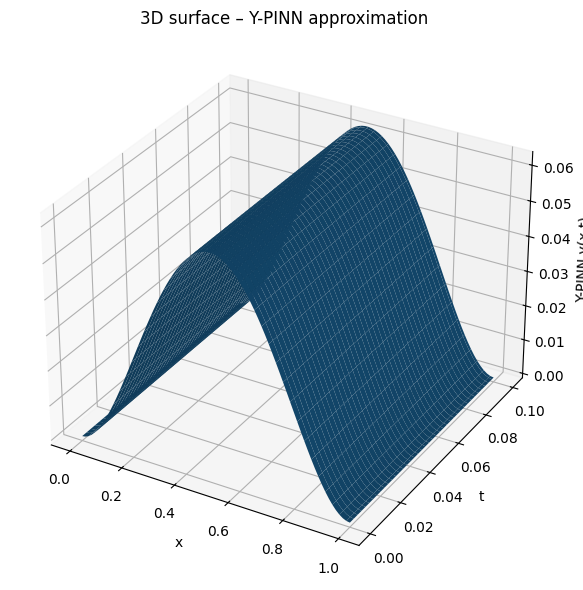

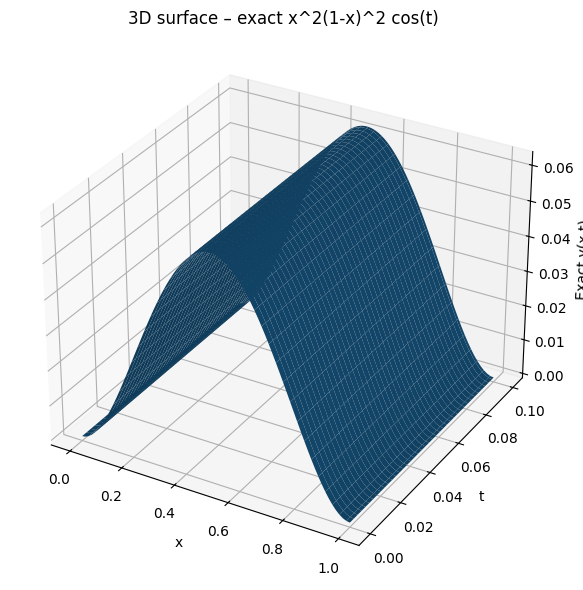

In [ ]:
# @title Comparison table: OR-OSPINN vs CFD/CBSQI/DQM
# Purpose: Compare OR-OSPINN errors with CFD, CBSQI, and DQM reference results.

import torch
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def y_exact(x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    """
    Exact solution y(x,t) = x^2 (1-x)^2 cos(t).
    x, t: tensors of the same shape, on `device`.
    """
    return (x**2) * (1.0 - x)**2 * torch.cos(t)

def l2_linf_slice_Y(N: int, t_star: float, interior_only: bool = True):
    """
    Compute (L2, Linf) errors of Y-PINN vs exact solution on [0,1]
    at fixed time t_star, using a uniform grid with N intervals.
    L2 ≈ sqrt( h * sum_j |e_j|^2 ), Linf = max_j |e_j|.
    """
    x = torch.linspace(0.0, 1.0, N + 1, device=device).unsqueeze(1)

    if interior_only and N >= 2:
        x_use = x[1:-1]
    else:
        x_use = x

    t_use = torch.full_like(x_use, float(t_star), device=device)
    xt    = torch.cat([x_use, t_use], dim=1)

    with torch.no_grad():
        y_p = Y(xt)
        y_e = y_exact(x_use, t_use)
        err = y_p - y_e

        h   = 1.0 / N
        L2  = torch.sqrt(h * torch.sum(err**2)).item()
        Linf = torch.max(torch.abs(err)).item()

    return float(L2), float(Linf)

table_data = {
    0.02: {
        20: (4.1658e-04, 5.9220e-04, 6.13641e-04),
        40: (1.0415e-04, 1.5420e-04, 1.39918e-04),
        60: (4.6287e-05, 6.9039e-05, 5.23068e-05),
    },
    0.10: {
        20: (4.1459e-04, 5.9201e-04, 4.29742e-04),
        40: (1.0365e-04, 1.5416e-04, 3.74392e-05),
        60: (4.6065e-05, 6.9021e-05, 3.44366e-05),
    }
}

times = [0.02, 0.10]
Ns    = [20, 40, 60]

rows = []
for t_star in times:
    for N in Ns:
        L2_Y, Linf_Y = l2_linf_slice_Y(N, t_star, interior_only=True)
        CFD, CBSQI, DQM = table_data[t_star][N]
        rows.append({
            "t": t_star,
            "N": N,
            "L2_Y_PINN":   L2_Y,
            "Linf_Y_PINN": Linf_Y,
            "CFD_Proposed": CFD,
            "CBSQI_[31]":   CBSQI,
            "DQM_[31]":     DQM,
        })

df = pd.DataFrame(rows).sort_values(by=["t", "N"]).reset_index(drop=True)

print("\nComparison table: Y-PINN vs exact x^2(1-x)^2 cos(t)")
print("(L2_Y_PINN and Linf_Y_PINN are errors of your method;")
print(" CFD/CBSQI/DQM are L∞ errors from the paper.)\n")
print(df.to_string(index=False, float_format=lambda x: f"{x:.3e}"))

def plot_3d_Y(t_min=0.0, t_max=0.10, Nx=80, Nt=80):
    """
    3D surface plot of Y-PINN approximation y(x,t) on [0,1] x [t_min,t_max].
    """
    x = torch.linspace(0.0, 1.0, Nx, device=device)
    t = torch.linspace(t_min, t_max, Nt, device=device)

    X, T = torch.meshgrid(x, t, indexing='ij')
    XT = torch.stack([X.reshape(-1), T.reshape(-1)], dim=1)

    with torch.no_grad():
        Y_pred = Y(XT).reshape(Nx, Nt).cpu().numpy()

    Xnp = X.cpu().numpy()
    Tnp = T.cpu().numpy()

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(Xnp, Tnp, Y_pred, linewidth=0, antialiased=True)
    ax.set_xlabel("x")
    ax.set_ylabel("t")
    ax.set_zlabel("Y-PINN y(x,t)")
    ax.set_title("3D surface – Y-PINN approximation")
    plt.tight_layout()
    plt.show()

def plot_3d_exact(t_min=0.0, t_max=0.10, Nx=80, Nt=80):
    """
    3D surface plot of exact solution x^2(1-x)^2 cos(t) on [0,1] x [t_min,t_max].
    """
    x = torch.linspace(0.0, 1.0, Nx, device=device)
    t = torch.linspace(t_min, t_max, Nt, device=device)

    X, T = torch.meshgrid(x, t, indexing='ij')
    x_flat = X.reshape(-1, 1)
    t_flat = T.reshape(-1, 1)

    with torch.no_grad():
        Y_exact = y_exact(x_flat, t_flat).reshape(Nx, Nt).cpu().numpy()

    Xnp = X.cpu().numpy()
    Tnp = T.cpu().numpy()

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(Xnp, Tnp, Y_exact, linewidth=0, antialiased=True)
    ax.set_xlabel("x")
    ax.set_ylabel("t")
    ax.set_zlabel("Exact y(x,t)")
    ax.set_title("3D surface – exact x^2(1-x)^2 cos(t)")
    plt.tight_layout()
    plt.show()

plot_3d_Y(t_min=0.0, t_max=0.10, Nx=80, Nt=80)
plot_3d_exact(t_min=0.0, t_max=0.10, Nx=80, Nt=80)
